In [3]:
# ==========================================
# 016_Time_Resolved_RSA.ipynb
# CELL 1: TIME-RESOLVED NWB EXTRACTION
# ==========================================
import os,sys 
import glob
import warnings
import numpy as np
import pandas as pd
from pynwb import NWBHDF5IO
from tqdm import tqdm

warnings.filterwarnings('ignore')

def get_sliding_window_counts(spike_times, delay_start, delay_end, window_size=0.5, step_size=0.05):
    """Converts raw spike times into a sliding window count array."""
    spike_times = np.array(spike_times)
    bin_starts = np.arange(delay_start, delay_end - window_size, step_size)
    binned_counts = np.zeros(len(bin_starts))
    bin_centers = bin_starts + (window_size / 2.0)

    for i, t_start in enumerate(bin_starts):
        t_end = t_start + window_size
        binned_counts[i] = np.sum((spike_times >= t_start) & (spike_times < t_end))

    return binned_counts, bin_centers

def extract_time_resolved_human_data(human_data_root, custom_cache_dir, target_regions, window_size=0.5, step_size=0.05):
    """
    Parses NWB files and Concept Cell CSVs to build time-resolved trial matrices.
    Returns:
    human_cells_dict: { 'sub-X_ses-Y_unitZ_region': (X_trials, y_binned_matrix, load_array) }
    """
    human_cells_dict = {}
    master_time_vector = None 
    
    csv_pattern = os.path.join(custom_cache_dir, "*_concept_cells.csv")
    csv_files = glob.glob(csv_pattern)
    print(f"Found {len(csv_files)} concept cell CSV files. Extracting time-resolved dynamics...")
    
    for csv_path in tqdm(csv_files):
        df_concepts = pd.read_csv(csv_path)
        df_target = df_concepts[df_concepts['location'].isin(target_regions)]
        if df_target.empty:
            print('empty df')
            continue
        print(len(df_target))
        # Extract Subject and Session
        filename = os.path.basename(csv_path)
        parts = filename.split('_')
        sub_id, ses_id = parts[0], parts[1]
        
        # Locate NWB
        nwb_search = os.path.join(human_data_root, "**", f"{sub_id}_{ses_id}*WorkingMemory*.nwb")
        nwb_matches = glob.glob(nwb_search, recursive=True)
        if not nwb_matches:
            nwb_matches = glob.glob(os.path.join(human_data_root, "**", f"{sub_id}_{ses_id}*.nwb"), recursive=True)
        if not nwb_matches:
            continue
            
        with NWBHDF5IO(nwb_matches[0], 'r') as io:
            nwb = io.read()
            trials_df = nwb.trials.to_dataframe().dropna(subset=['timestamps_Maintenance', 'timestamps_Probe'])
            
            for _, cell_row in df_target.iterrows():
                unit_id = int(cell_row['unit_id'])
                location = cell_row['location']
                
                try:
                    spike_times = nwb.units.get_unit_spike_times(unit_id)
                except:
                    continue
                
                X_trials, y_binned_list, loads_list = [], [], []
                
                for _, trial in trials_df.iterrows():
                    d_start = trial['timestamps_Maintenance']
                    d_end = trial['timestamps_Probe']
                    load = int(trial['loads'])
                    
                    # 1. Slide the Window
                    counts, centers = get_sliding_window_counts(spike_times, d_start, d_end, window_size, step_size)
                    
                    # 2. Jitter Protection: Lock all trials to the master time vector length
                    if master_time_vector is None:
                        master_time_vector = centers - d_start # Normalize time to start at 0.0s
                    
                    target_len = len(master_time_vector)
                    if len(counts) > target_len:
                        counts = counts[:target_len]
                    elif len(counts) < target_len:
                        counts = np.pad(counts, (0, target_len - len(counts)), 'constant')
                        
                    # 3. Extract Sequence
                    seq = [0, 0, 0] 
                    if load >= 1: seq[0] = int(trial['loadsEnc1_PicIDs'])
                    if load >= 2: seq[1] = int(trial['loadsEnc2_PicIDs'])
                    if load >= 3: seq[2] = int(trial['loadsEnc3_PicIDs'])
                    
                    X_trials.append(seq)
                    y_binned_list.append(counts)
                    loads_list.append(load)
                    
                cell_key = f"{sub_id}_{ses_id}_unit{unit_id}_{location}"
                human_cells_dict[cell_key] = (np.array(X_trials), np.array(y_binned_list), np.array(loads_list))

    print(f"\nExtraction complete! Formatted {len(human_cells_dict)} frontal concept cells.")
    print(f"Time-series structure: {len(master_time_vector)} bins per trial (Window: {window_size}s, Step: {step_size}s).")
    
    return human_cells_dict, master_time_vector

# ==========================================
# EXECUTE EXTRACTION
# ==========================================
human_data_root = "/Volumes/fetty/000469"
custom_cache_dir = "/Users/cwook/Documents/humac/data/concept_cells"
human_target_regions = [
	'pre_supplementary_motor_area_right', 
	'pre_supplementary_motor_area_left', 
	'dorsal_anterior_cingulate_cortex_right',
	'dorsal_anterior_cingulate_cortex_left'
]
tr_human_dict, time_bins = extract_time_resolved_human_data(
    human_data_root, 
    custom_cache_dir, 
    human_target_regions,
    window_size=0.5, 
    step_size=0.05
)

Found 17 concept cell CSV files. Extracting time-resolved dynamics...


  0%|          | 0/17 [00:00<?, ?it/s]

2


  6%|▌         | 1/17 [00:01<00:24,  1.55s/it]

1


...

empty df
empty df
4


 88%|████████▊ | 15/17 [00:05<00:00,  2.69it/s]

1


100%|██████████| 17/17 [00:06<00:00,  2.63it/s]

empty df

Extraction complete! Formatted 17 frontal concept cells.
Time-series structure: 43 bins per trial (Window: 0.5s, Step: 0.05s).


Sliding RSA across 43 time bins...


100%|██████████| 43/43 [00:00<00:00, 125.91it/s]


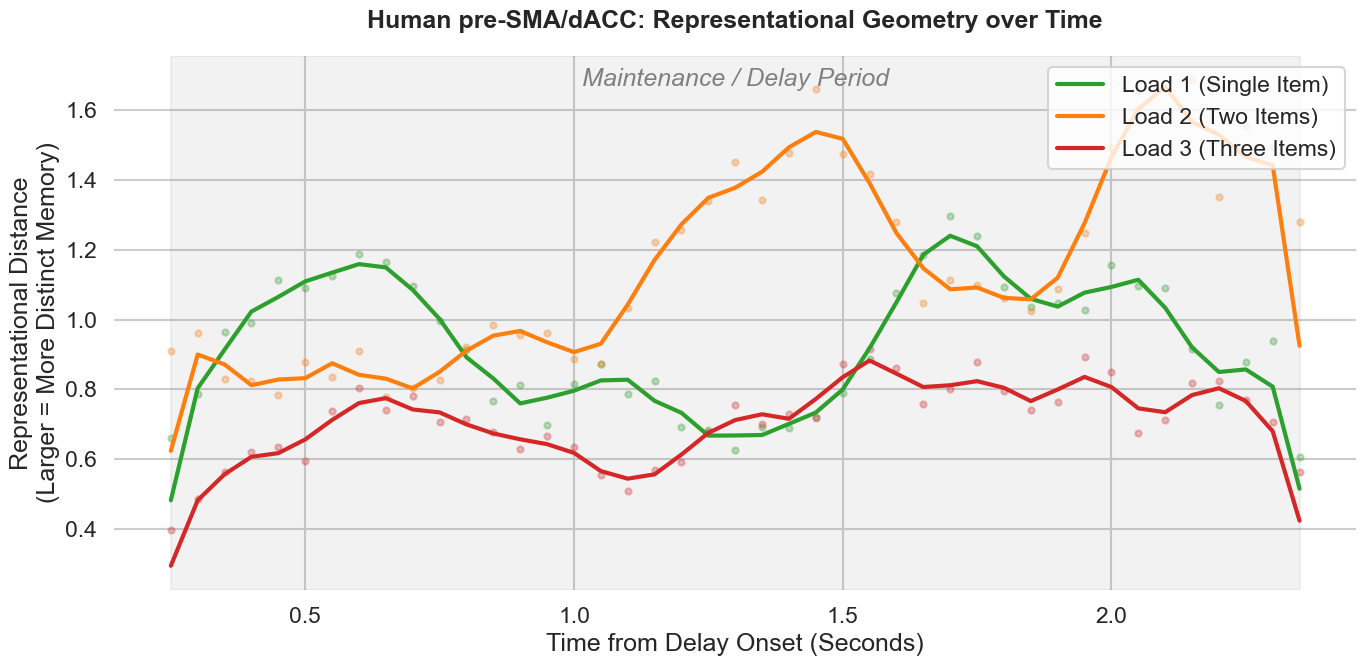

In [6]:
# ==========================================
# CELL 2: TIME-RESOLVED RSA & LOAD COMPRESSION
# ==========================================
import rsatoolbox
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def compute_sliding_rsa(cells_dict, time_bins, num_items=5, is_spatial=False):
    """
    Computes the Representational Dissimilarity Matrix (RDM) at every time bin 
    to track how representational geometry changes under different cognitive loads.
    
    Parameters:
    - is_spatial: False for Human (Temporal Sequence), True for Macaque (Spatial Array)
    """
    import rsatoolbox
    num_bins = len(time_bins)
    num_cells = len(cells_dict)
    
    # We will track the Mean Pairwise Distance between items for each Load
    dist_L1 = np.zeros(num_bins)
    dist_L2 = np.zeros(num_bins)
    dist_L3 = np.zeros(num_bins)
    
    print(f"Sliding RSA across {num_bins} time bins...")
    
    for t in tqdm(range(num_bins)):
        # Dynamically size the matrix based on species item count (e.g., 3 loads * 5 items = 15)
        pop_matrix = np.zeros((3 * num_items, num_cells))
        
        for n_idx, (cell_key, (X_trials, y_binned, loads)) in enumerate(cells_dict.items()):
            for l_idx, load_val in enumerate([1, 2, 3]):
                for item_val in range(1, num_items + 1):
                    
                    row_idx = (l_idx * num_items) + (item_val - 1)
                    
                    if not is_spatial:
                        # HUMAN (Time): Strictly lock to the first serial position (index 0)
                        mask = (loads == load_val) & (X_trials[:, 0] == item_val)
                    else:
                        # MACAQUE (Space): Cascade through available screen locations
                        mask = (loads == load_val) & (X_trials[:, 0] == item_val)
                        if np.sum(mask) == 0:
                            mask = (loads == load_val) & (X_trials[:, 1] == item_val)
                        if np.sum(mask) == 0:
                            mask = (loads == load_val) & (X_trials[:, 2] == item_val)
                            
                    if np.sum(mask) > 0:
                        pop_matrix[row_idx, n_idx] = np.mean(y_binned[mask, t])
                    else:
                        pop_matrix[row_idx, n_idx] = 0.0
                        
        # Calculate the RDM for this specific time slice
        dataset = rsatoolbox.data.Dataset(measurements=pop_matrix)
        rdm = rsatoolbox.rdm.calc_rdm(dataset, method='euclidean')
        dist_matrix = rdm.get_matrices()[0]
        
        # Helper function to extract the mean off-diagonal distance
        def get_mean_geometry(start_idx, end_idx):
            sub_matrix = dist_matrix[start_idx:end_idx, start_idx:end_idx]
            i, j = np.triu_indices(end_idx - start_idx, k=1)
            # Safety check in case of completely empty matrix slice
            if len(i) == 0: return 0.0 
            return np.mean(sub_matrix[i, j])
            
        # Dynamically extract the geometric sizes for each load at time T
        dist_L1[t] = get_mean_geometry(0, num_items)
        dist_L2[t] = get_mean_geometry(num_items, 2 * num_items)
        dist_L3[t] = get_mean_geometry(2 * num_items, 3 * num_items)
        
    return dist_L1, dist_L2, dist_L3
# 1. Run the RSA Pipeline
dist_L1, dist_L2, dist_L3 = compute_sliding_rsa(tr_human_dict, time_bins, num_items=5, is_spatial=False)

# 2. Smooth the data slightly for visual clarity (moving average)
def smooth(y, box_pts=3):
    box = np.ones(box_pts)/box_pts
    return np.convolve(y, box, mode='same')

smooth_L1 = smooth(dist_L1)
smooth_L2 = smooth(dist_L2)
smooth_L3 = smooth(dist_L3)

# ==========================================
# PLOTTING THE GEOMETRIC DYNAMICS
# ==========================================
sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(14, 7))

C_L1 = '#2ca02c' # Green
C_L2 = '#ff7f0e' # Orange
C_L3 = '#d62728' # Red

# Plot the smoothed trajectories
ax.plot(time_bins, smooth_L1, color=C_L1, lw=3, label='Load 1 (Single Item)')
ax.plot(time_bins, smooth_L2, color=C_L2, lw=3, label='Load 2 (Two Items)')
ax.plot(time_bins, smooth_L3, color=C_L3, lw=3, label='Load 3 (Three Items)')

# Add raw data points lightly in the background
ax.scatter(time_bins, dist_L1, color=C_L1, alpha=0.3, s=20)
ax.scatter(time_bins, dist_L2, color=C_L2, alpha=0.3, s=20)
ax.scatter(time_bins, dist_L3, color=C_L3, alpha=0.3, s=20)

ax.set_title("Human pre-SMA/dACC: Representational Geometry over Time", fontweight='bold', pad=20)
ax.set_xlabel("Time from Delay Onset (Seconds)")
ax.set_ylabel("Representational Distance\n(Larger = More Distinct Memory)")

# Highlight the delay period
ax.axvspan(time_bins[0], time_bins[-1], color='grey', alpha=0.1)
ax.text(time_bins[len(time_bins)//2], ax.get_ylim()[1] * 0.95, 
        'Maintenance / Delay Period', horizontalalignment='center', 
        fontstyle='italic', color='grey')

ax.legend(frameon=True, loc='upper right')
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("Figure_1_Time_Resolved_RSA_Human.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [7]:
# Setup Paths (Watters TensorFlow Dataset)
sys.path.append('../multi_object_memory_2025')
sys.path.append('../multi_object_memory_2025/phys_modeling')
sys.path.append('../multi_object_memory_2025/phys_modeling/training')
from phys_modeling.training.dataset import Dataset
# ==========================================
# CELL 3: TIME-RESOLVED MACAQUE EXTRACTION
# ==========================================
def strict_watters_filter(df):
	clean_units = df['quality'].isin(['good', '1', 'sua'])
	pos_sig = (df['Position AUC'] > 0.65) & (df['Position p-value'] < 0.05)
	id_sig = (df['Identity AUC'] > 0.65) & (df['Identity p-value'] < 0.05)
	is_probeloc = df['probe'] == 's0' 
	return df[clean_units & (pos_sig | id_sig) & is_probeloc]
    
def extract_time_resolved_macaque_data(session_list):
    print(f"\nExtracting Time-Resolved Data for {len(session_list)} sessions...")
    macaque_cells_dict = {}
    
    # 0 = empty screen position. 1, 2, 3 = objects
    concept_map = {'a': 1, 'b': 2, 'c': 3}
    
    # REVIEWER FIX: Ensure this filter ONLY looks for Identity AUC, not Position AUC
    # e.g., identity_only_filter = lambda df: (df['identity_auc'] > 0.65) & (df['identity_p'] < 0.05)
    from phys_modeling.training.dataset import Dataset
    
    for subject, session in session_list:
        try:
            # Swap 'strict_watters_filter' for your identity-only filter
            ds_delay = Dataset(subject=subject, session=session, phase="delay", 
                               unit_filter=strict_watters_filter, 
                               trial_filter=lambda df: df, max_n_objects=3)
                               
            # raw_neural shape: (n_trials, n_time_bins, n_neurons)
            raw_neural = ds_delay.data['neural'] 
            if raw_neural.shape[2] == 0: 
                continue
            
            # --- Aggressively Hunt for the DataFrame ---
            trials_df = None
            if isinstance(ds_delay.data, dict):
                for key, val in ds_delay.data.items():
                    if isinstance(val, pd.DataFrame):
                        trials_df = val
                        break       
            if trials_df is None:
                for attr in dir(ds_delay):
                    if not attr.startswith('_'):
                        try:
                            val = getattr(ds_delay, attr)
                            if isinstance(val, pd.DataFrame):
                                trials_df = val
                                break
                        except Exception:
                            pass
                            
            if trials_df is None:
                raise AttributeError("Could not find a pandas DataFrame.")
                
            if len(trials_df) != raw_neural.shape[0]:
                trials_df = trials_df[trials_df['completed'] == True]
            # ----------------------------------------------------
            
            X_trials = []
            loads_list = []
            
            for _, row in trials_df.iterrows():
                spatial_array = [0, 0, 0]
                load = int(row['num_objects'])
                
                if load >= 1 and pd.notna(row['object_0_location']):
                    spatial_array[int(row['object_0_location'])] = concept_map[row['object_0_id']]
                if load >= 2 and pd.notna(row['object_1_location']):
                    spatial_array[int(row['object_1_location'])] = concept_map[row['object_1_id']]
                if load >= 3 and pd.notna(row['object_2_location']):
                    spatial_array[int(row['object_2_location'])] = concept_map[row['object_2_id']]
                    
                X_trials.append(spatial_array)
                loads_list.append(load)
                
            X_trials = np.array(X_trials)
            loads_list = np.array(loads_list)
            n_neurons = raw_neural.shape[2]
            
            # Extract the time-binned matrix for each neuron
            for neuron_idx in range(n_neurons):
                # We KEEP the time bins instead of summing!
                # y_binned shape: (n_trials, n_time_bins)
                y_binned = raw_neural[:, :, neuron_idx]
                
                cell_key = f"{subject}_{session}_unit{neuron_idx}"
                # Save out the exact same tuple structure as the human pipeline
                macaque_cells_dict[cell_key] = (X_trials, y_binned, loads_list)
                
            print(f" -> {session} extracted ({n_neurons} DMFC neurons)")
            
        except Exception as e:
            print(f" -> Error on {session}: {e}")
            
    print(f"\nExtraction complete! Formatted {len(macaque_cells_dict)} Macaque DMFC cells.")
    
    # We also need to return a dummy time_bins array so the RSA function knows how many bins exist
    sample_key = list(macaque_cells_dict.keys())[0]
    num_bins = macaque_cells_dict[sample_key][1].shape[1]
    mac_time_bins = np.linspace(0, 1.5, num_bins) # Assuming 1.5s delay
    
    return macaque_cells_dict, mac_time_bins

# Execute
mac_shape = pd.read_csv('/Users/cwook/Documents/humac/lists/task_shape_inventory.csv')
macaque_sessions = []
for n,r in mac_shape[mac_shape['shape'] == 'Triangle'].iterrows():
    sub = r['file'].split('/')[0].replace('sub-','')
    ses = r['file'].split('/')[1].split('_')[1].replace('ses-','')
    macaque_sessions.append((sub,ses))

tr_mac_dict, mac_time_bins = extract_time_resolved_macaque_data(macaque_sessions)


Extracting Time-Resolved Data for 24 sessions...
Triangle session
Original number of trials: 2267
Original number of units: 203
Number of trials after filtering: 0
Number of units after filtering: 0
 -> Error on 2022-09-03: No units left after filtering
Triangle session
Original number of trials: 1512
Original number of units: 151
Number of trials after filtering: 1193
Number of units after filtering: 10
 -> 2022-09-02 extracted (10 DMFC neurons)
Triangle session
Original number of trials: 1578
Original number of units: 206
Number of trials after filtering: 1238
Number of units after filtering: 26
 -> 2022-08-31 extracted (26 DMFC neurons)
Triangle session
Original number of trials: 2847
Original number of units: 323
Number of trials after filtering: 1253
Number of units after filtering: 31
 -> 2022-08-19 extracted (31 DMFC neurons)
Triangle session
Original number of trials: 1954
Original number of units: 290
Number of trials after filtering: 1336
Number of units after filtering: 17


Sliding RSA across 100 time bins...


100%|██████████| 100/100 [00:20<00:00,  4.99it/s]


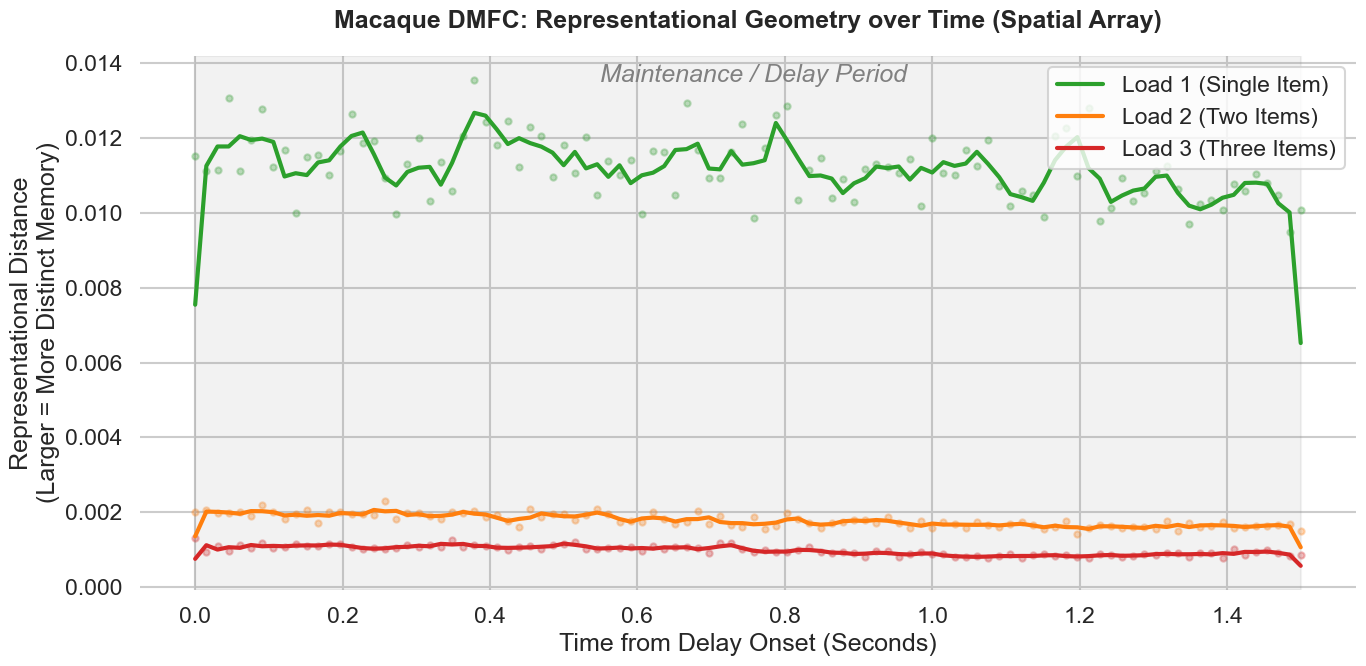

In [8]:
# ==========================================
# CELL 4: MACAQUE SPATIAL RSA & LOAD COMPRESSION
# ==========================================

# 1. Run the RSA Pipeline on the Macaque Data
# CRITICAL: num_items=3 for the macaque dataset
dist_L1_m, dist_L2_m, dist_L3_m = compute_sliding_rsa(tr_mac_dict, mac_time_bins, num_items=3, is_spatial=True)

# 2. Smooth the data for visual clarity
smooth_L1_m = smooth(dist_L1_m)
smooth_L2_m = smooth(dist_L2_m)
smooth_L3_m = smooth(dist_L3_m)

# ==========================================
# PLOTTING THE MACAQUE GEOMETRIC DYNAMICS
# ==========================================
sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(14, 7))

C_L1 = '#2ca02c' # Green
C_L2 = '#ff7f0e' # Orange
C_L3 = '#d62728' # Red

# Plot the smoothed trajectories
ax.plot(mac_time_bins, smooth_L1_m, color=C_L1, lw=3, label='Load 1 (Single Item)')
ax.plot(mac_time_bins, smooth_L2_m, color=C_L2, lw=3, label='Load 2 (Two Items)')
ax.plot(mac_time_bins, smooth_L3_m, color=C_L3, lw=3, label='Load 3 (Three Items)')

# Add raw data points lightly in the background
ax.scatter(mac_time_bins, dist_L1_m, color=C_L1, alpha=0.3, s=20)
ax.scatter(mac_time_bins, dist_L2_m, color=C_L2, alpha=0.3, s=20)
ax.scatter(mac_time_bins, dist_L3_m, color=C_L3, alpha=0.3, s=20)

ax.set_title("Macaque DMFC: Representational Geometry over Time (Spatial Array)", fontweight='bold', pad=20)
ax.set_xlabel("Time from Delay Onset (Seconds)")
ax.set_ylabel("Representational Distance\n(Larger = More Distinct Memory)")

# Highlight the delay period
# Assuming mac_time_bins spans the delay. Adjust if you extracted pre/post delay.
ax.axvspan(mac_time_bins[0], mac_time_bins[-1], color='grey', alpha=0.1)
ax.text(mac_time_bins[len(mac_time_bins)//2], ax.get_ylim()[1] * 0.95, 
        'Maintenance / Delay Period', horizontalalignment='center', 
        fontstyle='italic', color='grey')

ax.legend(frameon=True, loc='upper right')
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("Figure_2_Time_Resolved_RSA_Macaque.pdf", format='pdf', bbox_inches='tight')
plt.show()